# <center> TP n°1 - Filtrage adapté avec Python </center>

Ce TP présente le filtrage adapté qui permet d'obtenir le plus faible taux d'erreur binaire sur le récepteur dans le cas où le signal est bruité avec un bruit blanc gaussien. On effectuera une comparaison avec un récepteur sans filtre ou avec filtrage passe-bas classique.

## Import des modules

In [2]:
import importlib
import commNumv4
importlib.reload(commNumv4)
from commNumv4 import Modem
from commNumv4 import Mesure
from commNumv4 import Source
from commNumv4 import Canal
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal

## Ré-import d'une classe du module commNum en cas de modification

Si vous modifiez une classe du module commNum il faut la ré-importer. Par exemple si on a modifié la classe *Source*, il faudra relancer la cellule ci-dessous en commencant par ré-importer une autre classe par exemple *Mesure*, puis relancer un deuxième fois la cellule mais pour la classe *Source*. 

Pour être sûr que le ré-import s'est bien effectué, n'hesitez pas à mettre un print d'une chaîne de caractères différente à chaque ré-import dans votre classe.

<div class="alert alert-block alert-success">
        
## I. Etude du récepteur à filtre adapté/corrélateur pour une modulation PAM4
    
</div>

<div class="alert alert-block alert-info bilan">

### 1. Emetteur et canal AWGN

A l'aide du module commNum, créer un émetteur PAM4 transmettant un signal dans un canal AWGN avec les caractéristiques suivantes :  
    
    
- source : 1000 bits aléatoires  
- 4 symboles de modulation répartis entre 3 et -3  
- Filtre de mise en forme rectangulaire avec un upsampling de 8  
- Bruit blanc gaussien de moyenne nulle et de variance 0.6  
 
     
</div>

In [21]:
#génération de 1000 bits alétoires
bits = Source.random(1000)

#instanciation d'un modem PAM4
modemPAM4 = Modem('PAM', 4, bits)

#répartition des symboles de modulation entre 3 et -3
symbs_pam_trans = modemPAM4.mapping(3)

#signal PAM4 avec filtre de mise en forme rectangulaire et upsamling de 8
sig_pam_trans = modemPAM4.filtre_MF(symbs_pam_trans, 8)

#signal PAM4 bruité
sig_pam_bruite = Canal.awgn(sig_pam_trans, 0, 0.6)

<div class="alert alert-block alert-info bilan">

Affiche sur le même graphique le signal PAM4 et le signal bruité pour les 16 premiers symboles. Vous utiliserez des lignes pointillées avec des points pour le valeurs : `':o'`.
  
</div>

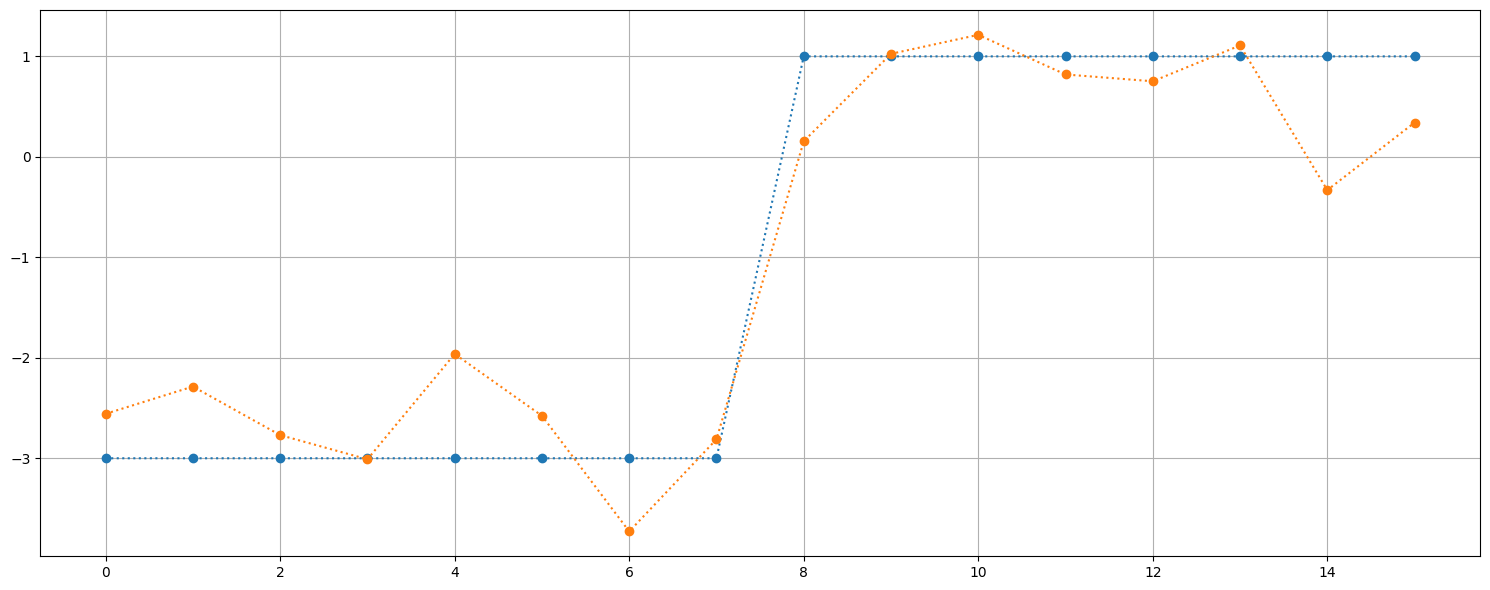

In [22]:
fig, ax = plt.subplots(figsize = (15, 6))

ax.plot(sig_pam_trans[0: 16], ':o')
ax.plot(sig_pam_bruite[0: 16], ':o')
ax.grid()

plt.tight_layout()

<div class="alert alert-block alert-info bilan">

### 2. Récepteur

On utilise 3 types de récepteur pour comparer leur taux d'erreur binaire :  
    
    
- **récepteur sans filtre** (downsampling, décision sur le symbole reçu et démapping)  
- **récepteur avec filtre passe-bas classique** (ajout d'un filtre  passe-bas pour améliorer le rapport signal sur bruit)  
- **récepteur avec filtre adapté** (ajout d'un filtre dit adapté correspondant à une corrélation   permettant de maximiser le rapport signal sur bruit aux instants de décisions)  
    

Si l'horloge du récepteur est configuré à la même fréquence que celle de l'émetteur, il existe en pratique un très léger écart en fréquence. De plus l'horloge du récepteur n'est pas synchronisé sur le signal reçu c'est à dire que si on prélève 1 échantillon par temps symbole, celui n'est pas forcément au à l'instant désiré et finit de toute façon par se décaler à cause de l'écart en fréquence entre l'horloge de l'émetteur et du récepteur.  
    
<br>    

Pour résoudre ce problème dit de synchronisation symboles, on prélève N échantillons par temps symbole,  et un algorithme (Gardner ou Muller-Muller par exemple) permet de détecter, à chaque symbole,  quel échantillon parmi les N est au milieu du temps symbole.  
    
<br> 
    
En simulation nous n'avons pas ce problème sauf dans le cas où nous utilisons un filtre qui introduit un retard par rapport aux échantillons émis. On décidera donc manuellement pour le premier symbole, quel échantillon retenir parmis les N lors de l'étape de downsampling.  
    
    
### 2.1 Récepteur sans filtre

A l'aide du module commNum, créer un récepteur sans filtre assurant :  
    
- le downsampling et en retenant l'échantillon au milieu du temps symbole  
- la décision par calcul de distance  
- le démapping  
    

Affiche sur le même graphique le signal reçu bruité et les échantillons retenus pour chaque symbole de modulation, pour les 16 premiers symboles. Vous utiliserez des lignes pointillées avec des points pour le valeurs : `':o'`.  
    
    
</div>

In [23]:
#downsampling du signal PAM4 bruité
symbs_pam_rcv = modemPAM4.downsample(sig_pam_bruite, 8, 4)

#décision par calcul de distance
symbs_pam_detect = modemPAM4.detection(symbs_pam_rcv)

#démapping des symboles de modulations reçues
bits_rcv = modemPAM4.demapping(symbs_pam_detect)

<div class="alert alert-block alert-info bilan">

**Taux d'erreur**   
    

Afficher (print) les 16 premiers symboles émis et reçus et le taux d'erreur symbole (sur l'ensemble des symboles). De même, afficher les 16 premiers bits émis et reçus et le taux d'erreur binaire (1 chiffre après la virgule).  
    
<br> 
    
On pourra utiliser la fonction `sum` pour le taux d'erreur en % comme illustré ci-dessous :  
    
`TE = (sum(0 + (symbs_trans - symbs_detect) !=0) / len(symbs_trans)) * 100`

</div>

In [24]:
#calcul du taux d'erreur entre les symboles émis et les symboles reçus
taux_erreur = (sum(0 + (symbs_pam_trans - symbs_pam_detect) != 0) / len(symbs_pam_trans)) * 100
print(f"Le taux d'erreur est de {taux_erreur}%")

Le taux d'erreur est de 7.6%


<div class="alert alert-block alert-info bilan">

### 2.2 Récepteur avec filtre passe-bas classique

L'essentiel de la puissance du signal est concentré dans son premier lobe alors que la puissance du bruit est répartie sur toutes les fréquences (bruit blanc). Pour améliorer le rapport entre la puissance du signal et la puissance du bruit, on va filtrer le signal à son premier lobe conservant ainsi l'essentiel de la puissance du signal et seulement un tout petit peu de la puissance du bruit.

<!-- Image dans le même répertoire ![emetteur N mod complexe](images/DSP bruit BB.png) -->

<img src="https://lh3.googleusercontent.com/d/1jvmZzciXPnFJyvZLG533Mu0XWy6V73LT" align=center width="500">
    
1. On suppose que le débit binaire est de 2KBits/s. En déduire la rapidité des symboles de modulation compte tenu de la modulation utilisée et la fréquence d'échantillonnage compte tenu du facteur de upsampling.  
    
    
2. Créer un filtre passe-bas (avec la méthode scipy.signal.butter) avec les caractéristiques suivante:
- Ordre 3
- Fréquence de coupure égale à la largeur du lobe principal   
    
    
3. Filtrer le signal reçu avec ce filtre.  
    

4. Affiche le signal PAM4 émis et le signal bruité sur le même graphique. Afficher le signal filtré sur un second graphique. Vous utiliserez des lignes pointillées avec des points pour les valeurs : `':o'`.
 
</div>

1) La modulation PAM4 utilise 2 bits par symbole, sachant que le debit D vaut 2000 bits/s, alors la rapidité de modulation R vaut D/2 soit R = 1000 symboles/s. <br>On sait que fe = R * umpsampling, donc fe = 500 * 8 = 4000 échantillons/s.

In [25]:
#paramètres de la modulation
R = 1000
fe = 8000
downsampling = 8

2. 

In [26]:
#paramètres du filtre
ordre = 3
fc = R

3. 

In [27]:
#filtrage passe-bas du signal PAM4
fcn = fc/(fe/2)
b, a = scipy.signal.butter(ordre, fcn, btype='low')
sig_pam_filtre = 2*scipy.signal.lfilter(b, a, sig_pam_bruite)

4. 

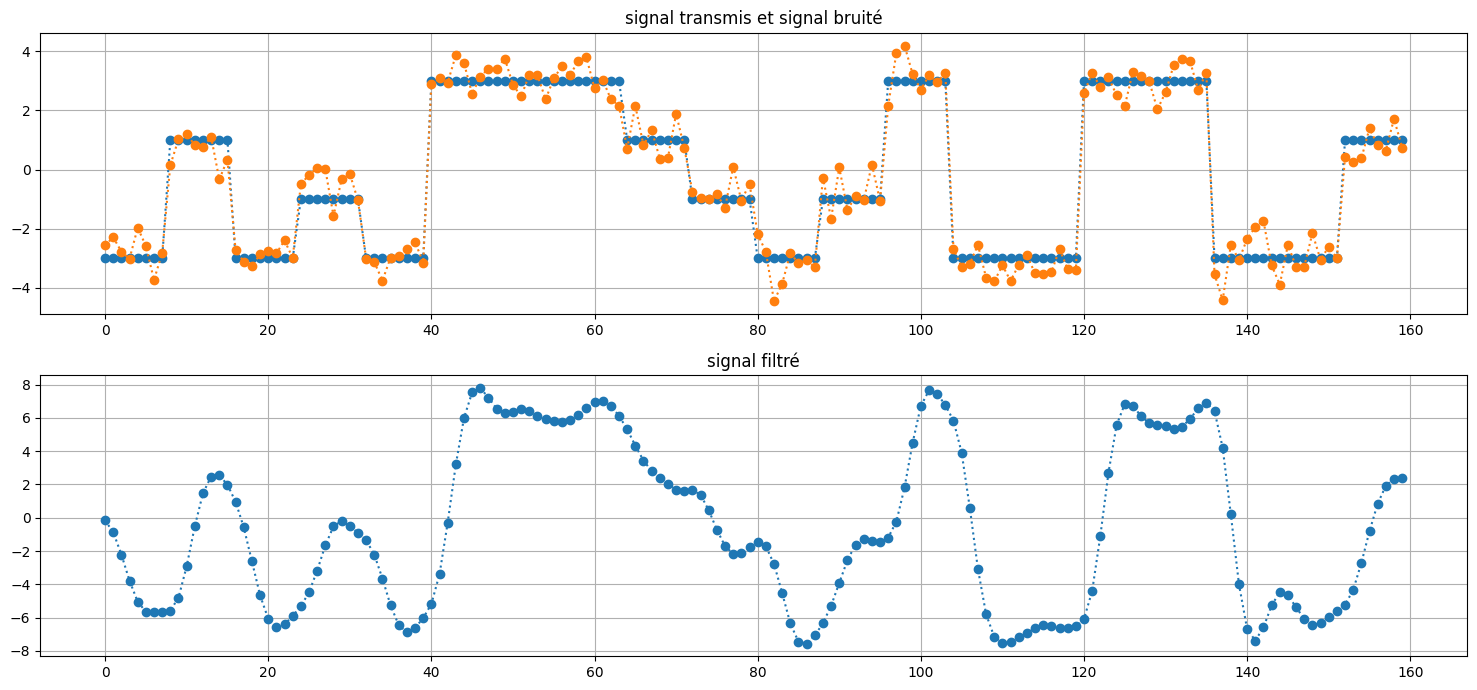

In [28]:
#affichage du signal transmis, bruité et filtré
fig, ax = plt.subplots(2, 1, figsize = (15, 7))

ax[0].plot(sig_pam_trans[0: 160], ':o')
ax[0].plot(sig_pam_bruite[0: 160], ':o')
ax[0].set_title("signal transmis et signal bruité")
ax[0].grid()
ax[1].plot(sig_pam_filtre[0: 160], ':o')
ax[1].set_title("signal filtré")
ax[1].grid()

plt.tight_layout()

<div class="alert alert-block alert-info bilan">

**Réception avec synchronisation manuelle**

Comme vous pouvez le voir sur la figure précédente, le filtre introduit un retard par rapport au signal à son entrée. Normalement un algortihme de synchronisation vient après le filtre, effectuer le downsampling en choisissant l'échantillon à chaque symbole qui permet de minimiser le taux d'erreur. 
    
Ici nous le ferons de manière manuelle avec la méthode downsampling en choisissant le décalage qui donnera le plus faible taux d'erreur. 
    
Effectuer le downsampling pour un décalage de 4 échantillons, la détection et le démapping
 
</div>

In [29]:
#dowsampling du signal filtré
symbs_pam_rcv_filtre = modemPAM4.downsample(sig_pam_filtre, downsampling, 4)

#detection des symboles de modulations filtrés
symbs_pam_detect_filtre = modemPAM4.detection(symbs_pam_rcv_filtre)

#démaping des symboles de modulations
bits_rcv_filtre = modemPAM4.demapping(symbs_pam_detect_filtre)

<div class="alert alert-block alert-info bilan">

**Taux d'erreur**  
    
<br>    
Afficher (print) les 16 premiers symboles émis et reçus et le taux d'erreur symbole (sur l'ensemble des symboles). De même afficher les 16 premiers bits émis et reçus et le taux d'erreur binaire (1 chiffre après la virgule).

</div>

In [30]:
#affichage des 16 premiers symboles transmis et reçus
print(f"Symboles transmis : {symbs_pam_trans[0: 16]}\n")
print(f"Symboles reçus avec filtrage passe-bas : {symbs_pam_rcv_filtre[0: 16]}\n")

#calcul du taux d'erreur entre les symboles transmis et les symboles reçus
taux_erreur_symb = (sum(0 + (symbs_pam_trans - symbs_pam_detect_filtre) != 0) / len(symbs_pam_trans)) * 100
print(f"Le taux d'erreur entre les symboles transmis et reçus est de {taux_erreur_symb}%\n")

#affichage des 16 premiers bits transmis et reçus
print(f"Bits transmis : {bits[0: 16]}\n")
print(f"Bits reçus avec filtrage passe-bas : {bits_rcv_filtre[0: 16]}\n")

#calcul du taux d'erreur entre les bits transmis et les bits reçus
taux_erreur_bin = (sum(0 + (bits - bits_rcv_filtre) != 0) / len(bits)) * 100
print(f"Le taux d'erreur est de {taux_erreur_bin}%")

Symboles transmis : [-3.  1. -3. -1. -3.  3.  3.  3.  1. -1. -3. -1.  3. -3. -3.  3.]

Symboles reçus avec filtrage passe-bas : [-5.0501955   1.47076043 -6.07119165 -0.51778441 -6.45916897  5.99722609
  6.40185235  6.93537731  2.40338435 -1.69951526 -6.35236944 -1.6128631
  6.72368023 -5.80231433 -6.49276646  5.57651102]

Le taux d'erreur entre les symboles transmis et reçus est de 23.400000000000002%

Bits transmis : [0 0 1 0 0 0 0 1 0 0 1 1 1 1 1 1]

Bits reçus avec filtrage passe-bas : [0 0 1 0 0 0 0 1 0 0 1 1 1 1 1 1]

Le taux d'erreur est de 11.700000000000001%


<div class="alert alert-block alert-info bilan">

**Impact de l'instant d'échantillonnage sur le taux d'erreur**
    
Relancer vos 2 cellules de codes précédentes pour voir le taux d'erreur si le décalage est successivement de 3 échantillons, puis 5 puis 6. Noter les résultats dans la cellule ci-dessous et conclure.

</div>

<div class="alert alert-block alert-info bilan">

### 2.3 Récepteur avec filtre adapté

Pour ce récepteur on utilise un filtre adapté qui conste à faire un moyenne glissante (pour un filtre de mise en forme rectangulaire en émission) sur les n échantillons par symbole.  
    
<br/>

Le module commNum dispose d'une méthode nommée `moy_glissante`pour effectuer le filtrage adapté dans le cas d'un filtre de mise en forme rectangulaire sur l'émetteur.  

<br/>  
    
**Fonctionnement du corrélateur sur un signal non bruité**  
    
<br>
Effectuer la réception en prenant comme signal reçu le signal émis (non bruité). Afficher pour les 16 premiers symboles le signal émis, le signal après le corrélateur et après downsampling sur le même graphique. Vous prendrez un décalage de 7 pour le dowsampling et vérifirez qu'il s'agit bien du bon échantillon devant être retenu pour chaque symbole de modulation.
    
</div>

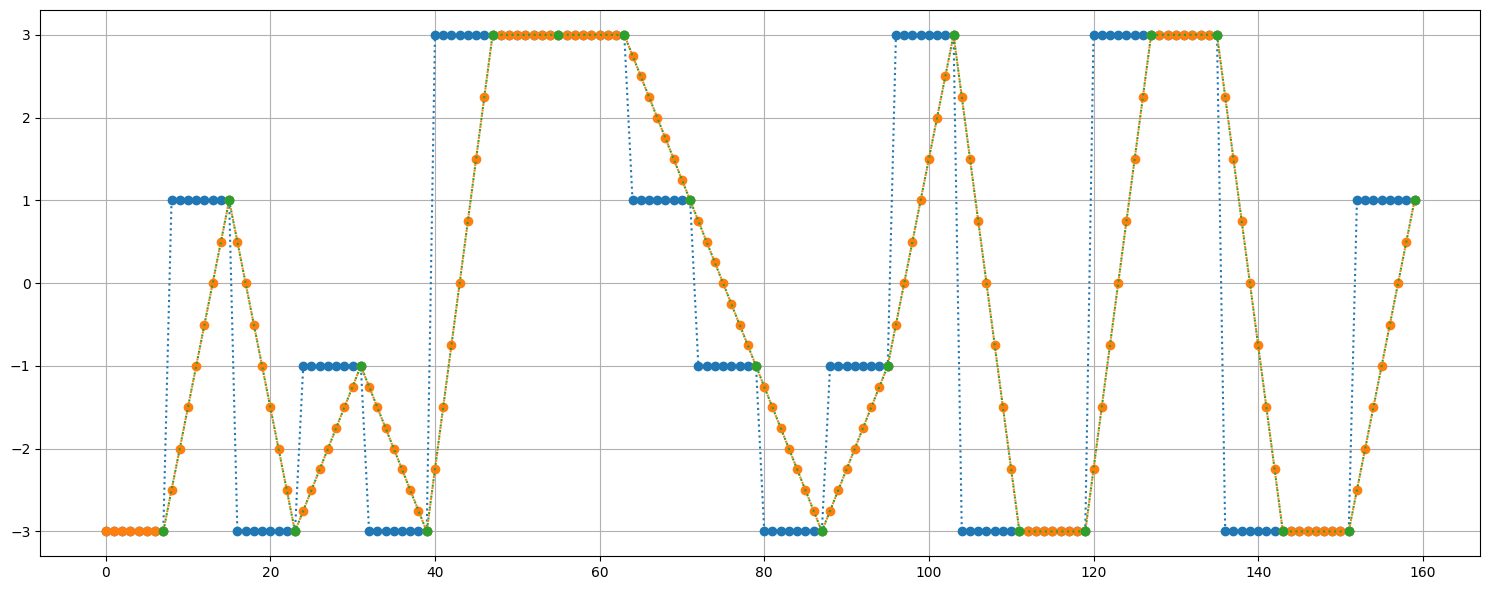

In [ ]:
offset = 7

#filtre à correlateur
sig_pam_moy_gliss = modemPAM4.filtre_rcv(sig_pam_trans, "moy_glissante", fc, fe)

#dowsampling
symbs_pam_moy_glissante = modemPAM4.downsample(sig_pam_moy_gliss, downsampling, offset)

#affichage du signal émis, avec filtre à corrélateur
fig, ax = plt.subplots(figsize = (15, 6))

#vecteur des échantillons pour synchronisser l'affichage
ech = np.arange(offset,len(sig_pam_moy_gliss), downsampling)


ax.plot(sig_pam_trans[0: 160], ':o')
ax.plot(sig_pam_moy_gliss[0: 160], ':o')
ax.plot(ech[0: int(160/downsampling)], symbs_pam_moy_glissante[0: int(160/downsampling)], ':o')
ax.grid()

plt.tight_layout()

<div class="alert alert-block alert-info bilan">

**Fonctionnement du filtre adapté avec le signal bruité**  
    
<br>
Effectuer la réception avec signal bruité. Afficher pour les 16 premiers symboles : le signal émis, le signal après le corrélateur et après downsampling sur le même graphique.
    
</div>

<div class="alert alert-block alert-info bilan">

**Taux d'erreur avec le récepteur à corrélateur**   
    
<br>    
Afficher (print) les 16 premiers symboles émis et reçus et le taux d'erreur symbole (sur l'ensemble des symboles). De même afficher les 16 premiers bits émis et reçus et le taux d'erreur binaire (1 chiffre après la virgule).

</div>

<div class="alert alert-block alert-success">
        
## II. Etude du récepteur à filtre adapté/corrélateur pour une modulation 16QAM
    
</div>

<div class="alert alert-block alert-info bilan">

### 1. Rappels sur la réception sur fréquence avec filtre passe-bas pour une modulation 16QAM  
    
<br>    

On rappelle ci-dessous le code Python pour simuler une transmission 16QAM dans un canal AWGN avec le module commNum.  Le filtre passe-bas au niveau du récepteur permet de filtrer les composantes spectrales à $-2.f_p$ après la donwconversion ainsi que le bruit.  
    
<br>  

**Rappel sur le récepteur 16QAM à filtre passe-bas**   

<br>   
   
Exécuter la cellule ci-dessous et la cellule suivante pour vous remémorer l'allure temporelle des signaux à différents endroits de la chaîne de transmission.  Le bruit est pour l'instant nul.  

</div>

In [32]:
# ###############################################
# #### Caractéristiques de la transmission #####
# ###############################################
# #Emetteur
# D = 400
# nsymb = 16
# bits_per_symp = int(np.log2(nsymb))
# tb = 1/D
# fe = 10000
# te = 1/fe
# ts = bits_per_symp*tb
# R = 1/ts
# fp = 500
# upsampling = int(fe/R)
# #Canal
# mean = 0
# std = 1.2
# #Récepteur
# downsample_factor = upsampling

# ###############################################
# ##########          Emetteur         ##########
# ###############################################
# #Source
# mydata = Source()
# bits = mydata.random(5000)
# #Création et initialisation des paramètres du modem (création de l'objet)
# QAM_mod = Modem('QAM', 16 , bits)
# #Mapping
# symbs_QAM=QAM_mod.mapping(3)
# #Filtre de mise en forme rectangulaire
# bb_QAM = QAM_mod.filtre_MF(symbs_QAM, upsampling, 'rectangular')
# #Translation de fréquence upconversion
# sig_QAM = QAM_mod.upconv(bb_QAM, fp, te)

# ###############################################
# ##########          Canal AWGN       ##########
# ###############################################
# mycanal = Canal()
# QAM_bruite = mycanal.awgn(sig_QAM, mean, std)

# ##########################################################
# ##########  Récepteur à filtre passe-bas classique  ######
# ##########################################################
# #Translation de fréquence downconversion
# down1_QAM1 = QAM_mod.downconv(QAM_bruite, fp, te)
# #Filtrage à fp
# ordre=5
# fcn=fp/(fe/2)
# b, a = scipy.signal.butter(ordre, fcn, btype='low')
# down2_QAM1=2*scipy.signal.lfilter(b, a, down1_QAM1)
# #Downsampling
# decalage1 = 65
# symbs_rcv1 = QAM_mod.downsample(down2_QAM1, downsample_factor, decalage1)
# #Détection
# symbs_detect1 = QAM_mod.detection(symbs_rcv1)
# #Démapping
# bits_rcv1 = QAM_mod.demapping(symbs_detect1)

In [33]:
# #Affichage du signal reçu et du signal filtré
# nsymb_aff = 16
# fig, ax = plt.subplots(2,1, figsize = (15, 10))
# ax[0].plot(QAM_bruite[0:nsymb_aff*upsampling])
# ax[0].grid()
# ax[0].set_title("Signal modulé 16QAM", fontsize = 16)
# ax[1].plot(np.real(down2_QAM1[0:nsymb_aff*upsampling]), ':o')
# ax[1].plot(np.imag(down2_QAM1[0:nsymb_aff*upsampling]), ':o')
# ax[1].set_title("Partie réelle et imaginaire des symboles de modulation obtenus \naprès \
#  donwconversion et filtrage passe-bas et échantillon retenu à chaque symbole", fontsize = 16)
# num_ech = np.arange(decalage, len(down2_QAM1[0:nsymb_aff*upsampling]), upsampling)
# ax[1].plot(num_ech, np.real(symbs_rcv1[0:nsymb_aff]), 'o', mew=4)
# ax[1].plot(num_ech, np.imag(symbs_rcv1[0:nsymb_aff]), 'o', mew=4)
# ax[1].grid()
# plt.tight_layout()

<div class="alert alert-block alert-info bilan">

### 2. Remplacement du filtre passe-bas par un filtre adapté  
    
<br>
    
On souhaite remplacer le filtre passe-bas au niveau du récepteur par un filtre adapté pour améliorer le taux d'erreur. Reprendre le code du récepteur en remplaçant le filtre passe-bas par un filtre adapté c'est à dire un simple moyenne glissante dans le cas d'un filtre de mise en forme rectangulaire.  
    
<br>
    
Afficher la partie réelle et imaginaires et symboles de modulation et des échantillons retenus à chaque symbole (vous prendrez un décalage de `downsample_factor-1`).

</div>

<div class="alert alert-block alert-info bilan">

**Impact du bruit blanc gaussien sur les signaux**

Relancer les cellules précédente mais pour un bruit blanc gaussien avec une variance de 1.2 et visualiser les signaux pour le récepteur avec filtre passe-bas et filtre adapté.

</div>

<div class="alert alert-block alert-info bilan">

### 3. Comparaison des taux d'erreur

Calculer les taux d'erreur symboles pour les 2 récepteurs et conclure sur le filtrage adapté.

</div>